# Economic Significance V3 - DCA Accelerat cu V5 Ensemble
**Strategie:** DCA saptamanal cu accelerare in perioadele de V-shape recovery

**Logica:** In saptamani Non-V economisesti $100 in cash (T-bills).
In saptamani V-shape investesti $100 + tot cash-ul acumulat.

**Garantie:** Ambele portofolii investesc exact acelasi total de bani.

**Benchmark:** DCA simplu $100/saptamana indiferent de semnal.

## 1. Import si Incarcare Model

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import pickle
import os
import warnings
warnings.filterwarnings('ignore')
from fredapi import Fred

os.makedirs('plots', exist_ok=True)

ensemble = pickle.load(open('../V5/models/v5_ensemble.pkl', 'rb'))
scaler   = pickle.load(open('../V5/models/v5_scaler.pkl',   'rb'))

with open('../V5/models/v5_model_meta.json') as f:
    meta = json.load(f)

FEATURE_COLS      = meta['feature_cols']
OPTIMAL_THRESHOLD = meta['optimal_threshold']
WEEKLY_BUDGET     = 100   # $100 pe saptamana in ambele portofolii

print('Model:', meta['model_name'], '| AUC:', meta['auc'])
print('Threshold:', OPTIMAL_THRESHOLD)
print('Budget saptamanal:', WEEKLY_BUDGET, '$')

Model: Voting Ensemble | AUC: 0.804
Threshold: 0.62
Budget saptamanal: 100 $


## 2. FRED API Key

In [2]:
FRED_API_KEY = '9cbb31e1e8aeea0f649895cfc852dce7'
fred = Fred(api_key=FRED_API_KEY)
print('FRED API conectat.')

FRED API conectat.


## 3. Descarcare Date si Feature Engineering

In [24]:
START_DATA     = '2016-01-01'   # pentru rolling windows (MA200 etc.)
START_BACKTEST = '2017-01-01'   # inceputul backtestului
END_BACKTEST   = '2026-04-14'   # azi

sp500 = yf.download('^GSPC', start=START_DATA, end=END_BACKTEST, auto_adjust=True)
sp500 = sp500[['Close', 'Volume']].copy()
sp500.columns = ['SP500_Close', 'SP500_Volume']

vix = yf.download('^VIX', start=START_DATA, end=END_BACKTEST, auto_adjust=True)
vix = vix[['Close']].copy()
vix.columns = ['VIX_raw']

daily = sp500.join(vix, how='left')
daily.index = pd.to_datetime(daily.index)

FALLBACK_VALUES = {
    'Yield_Curve'   : 0.50,
    'Jobless_Claims': 300000,
    'Credit_Spread' : 3.50,
    'Dollar_Index'  : 90.0,
    'Fed_Rate'      : 2.50
}

fred_series = {
    'Yield_Curve'   : ['T10Y2Y', 'T10Y3M', 'DGS10'],
    'Jobless_Claims': ['ICSA', 'IC4WSA'],
    'Credit_Spread' : ['BAMLH0A0HYM2', 'BAMLC0A0CBBB'],
    'Dollar_Index'  : ['DTWEXM', 'DTWEXBGS'],
    'Fed_Rate'      : ['FEDFUNDS', 'DFF', 'DFEDTARU']
}

macro_raw = pd.DataFrame()
for name, codes in fred_series.items():
    success = False
    for code in codes:
        try:
            series = fred.get_series(code, observation_start=START_DATA,
                                     observation_end=END_BACKTEST)
            if series.dropna().empty:
                continue
            series.name = name
            macro_raw = macro_raw.join(series, how='outer') if not macro_raw.empty else series.to_frame()
            print(name.ljust(20), '| OK:', code, '| Ultima val:', round(series.dropna().iloc[-1], 3))
            success = True
            break
        except:
            continue
    if not success:
        macro_raw[name] = FALLBACK_VALUES.get(name, 0.0)
        print(name.ljust(20), '| FALLBACK:', FALLBACK_VALUES.get(name, 0.0))

macro_raw.index = pd.to_datetime(macro_raw.index)
macro_raw = macro_raw.ffill().bfill()

df = daily.join(macro_raw, how='left').ffill().bfill()

# Features tehnice
df['MA50']             = df['SP500_Close'].rolling(50).mean()
df['MA200']            = df['SP500_Close'].rolling(200).mean()
df['Dist_MA50']        = (df['SP500_Close'] - df['MA50'])  / df['MA50']
df['Dist_MA200']       = (df['SP500_Close'] - df['MA200']) / df['MA200']
df['Dist_52w_High']    = (df['SP500_Close'] - df['SP500_Close'].rolling(252).max()) / df['SP500_Close'].rolling(252).max()
df['Return_1d']        = df['SP500_Close'].pct_change()
df['Realized_Vol_10d'] = df['Return_1d'].rolling(10).std() * np.sqrt(252)
df['Local_Min_20d']    = df['SP500_Close'].rolling(20).min()
df['Dist_Local_Min']   = (df['SP500_Close'] - df['Local_Min_20d']) / df['Local_Min_20d']
df['VIX_MA60']         = df['VIX_raw'].rolling(60).mean()
df['VIX_Ratio']        = df['VIX_raw'] / df['VIX_MA60']

delta = df['SP500_Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain / loss))

def rolling_slope(series, window):
    slopes = [np.nan] * len(series)
    vals, x = series.values, np.arange(window)
    for i in range(window - 1, len(vals)):
        y = vals[i - window + 1 : i + 1]
        if not np.any(np.isnan(y)):
            slopes[i] = np.polyfit(x, y, 1)[0]
    return pd.Series(slopes, index=series.index)

df['VIX_Trend_20d']   = rolling_slope(df['VIX_raw'], 20)
df['SP500_Trend_20d'] = rolling_slope(df['SP500_Close'], 20)

df['Yield_Curve_Change'] = df['Yield_Curve'].diff(20)
df['Jobless_MA12']       = df['Jobless_Claims'].rolling(60).mean()
df['Jobless_Ratio']      = df['Jobless_Claims'] / df['Jobless_MA12']
df['Dollar_Change']      = df['Dollar_Index'].pct_change(4).fillna(0.0)

agg_rules = {
    'SP500_Close': 'last', 'SP500_Volume': 'sum', 'VIX_raw': 'mean',
    'Dist_MA50': 'last', 'Dist_MA200': 'last', 'Dist_52w_High': 'last',
    'RSI': 'last', 'Dist_Local_Min': 'last', 'VIX_Ratio': 'mean',
    'VIX_Trend_20d': 'mean', 'SP500_Trend_20d': 'last',
    'Realized_Vol_10d': 'mean', 'Yield_Curve': 'mean',
    'Yield_Curve_Change': 'last', 'Jobless_Ratio': 'mean',
    'Dollar_Change': 'last'
}
for col in ['Credit_Spread', 'Fed_Rate']:
    if col in df.columns:
        agg_rules[col] = 'mean' if col == 'Credit_Spread' else 'last'

weekly = df.resample('W-FRI').agg(agg_rules)
weekly = weekly.rename(columns={'VIX_raw': 'VIX'})
weekly['Return_1w']    = weekly['SP500_Close'].pct_change()
weekly['Return_4w']    = weekly['SP500_Close'].pct_change(4)
weekly['Volume_Ratio'] = weekly['SP500_Volume'] / weekly['SP500_Volume'].rolling(8).mean()
weekly = weekly.loc[:, ~weekly.columns.duplicated()]

for col, val in [('Credit_Spread', 3.50), ('Fed_Rate', 2.50)]:
    if col not in weekly.columns:
        weekly[col] = val

weekly = weekly.ffill()
weekly.dropna(subset=['Return_1w'], inplace=True)

weekly_bt        = weekly[weekly.index >= START_BACKTEST].copy()
weekly_bt['Phase'] = 1

print('Saptamani backtest:', len(weekly_bt))
print('Perioada:', weekly_bt.index[0].date(), '->', weekly_bt.index[-1].date())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Yield_Curve          | OK: T10Y2Y | Ultima val: 0.52
Jobless_Claims       | OK: ICSA | Ultima val: 219000.0
Credit_Spread        | OK: BAMLH0A0HYM2 | Ultima val: 2.94
Dollar_Index         | OK: DTWEXM | Ultima val: 90.822
Fed_Rate             | OK: FEDFUNDS | Ultima val: 3.64
Saptamani backtest: 485
Perioada: 2017-01-06 -> 2026-04-17


## 4. Predictii Saptamanale

In [25]:
X_bt = pd.DataFrame(
    np.zeros((len(weekly_bt), len(FEATURE_COLS))),
    columns=FEATURE_COLS, index=weekly_bt.index
)
for col in FEATURE_COLS:
    if col in weekly_bt.columns:
        X_bt[col] = weekly_bt[col].fillna(0.0).values

proba  = ensemble.predict_proba(scaler.transform(X_bt.values))[:, 1]
signal = (proba >= OPTIMAL_THRESHOLD).astype(int)

# Shift de o saptamana: semnalul din t se aplica in t+1
signal_s = pd.Series(signal, index=weekly_bt.index).shift(1).fillna(0).astype(int)
proba_s  = pd.Series(proba,  index=weekly_bt.index).shift(1).fillna(0)

n_vshape = signal_s.sum()
n_nonv   = (signal_s == 0).sum()
pct_v    = round(signal_s.mean() * 100, 1)

print('Saptamani V-shape (acumulare accelerata):', n_vshape, '(' + str(pct_v) + '%)')
print('Saptamani Non-V   (economisire cash):     ', n_nonv,  '(' + str(round(100-pct_v, 1)) + '%)')

Saptamani V-shape (acumulare accelerata): 34 (7.0%)
Saptamani Non-V   (economisire cash):      451 (93.0%)


## 5. Simulare DCA

**DCA Simplu:** $100 in fiecare saptamana, la pretul de inchidere vineri.

**DCA Accelerat:**
- Saptamani Non-V: $100 merge in cash (la dobanda T-bill)
- Saptamani V-shape: investesti $100 + tot cash-ul acumulat

**Garantie:** Total investit in SP500 + cash = acelasi in ambele portofolii.

In [30]:
prices    = weekly_bt['SP500_Close'].values
tbill_w   = (weekly_bt.get('Fed_Rate', pd.Series(2.5, index=weekly_bt.index)) / 100 / 52).values
signals   = signal_s.values
n_weeks   = len(weekly_bt)

# --- DCA Simplu ---
dca_shares     = 0.0
dca_total_inv  = 0.0
dca_shares_log = []
dca_value_log  = []
dca_invested_log = []

for i in range(n_weeks):
    if prices[i] > 0:
        shares_bought  = WEEKLY_BUDGET / prices[i]
        dca_shares    += shares_bought
        dca_total_inv += WEEKLY_BUDGET
    dca_shares_log.append(dca_shares)
    dca_value_log.append(dca_shares * prices[i])
    dca_invested_log.append(dca_total_inv)

# --- DCA Accelerat ---
BASE_INVEST  = 70
CASH_SAVE    = 30

# Threshold-uri pentru cele 3 niveluri
T_LOW  = 0.30   # sub acesta: economisesti tot
T_HIGH = OPTIMAL_THRESHOLD  # peste acesta: accelerezi complet

acc_shares       = 0.0
acc_cash         = 0.0
acc_total_inv    = 0.0
acc_shares_log   = []
acc_value_log    = []
acc_cash_log     = []
acc_invested_log = []

for i in range(n_weeks):
    p = proba_s.iloc[i]  # probabilitatea din saptamana curenta

    # Cumparati mereu $70 de baza
    if prices[i] > 0:
        acc_shares += BASE_INVEST / prices[i]

    if p >= T_HIGH:
        # Semnal puternic: $30 saptamanal + tot cash-ul acumulat
        deploy      = CASH_SAVE + acc_cash
        acc_shares += deploy / prices[i]
        acc_cash    = 0.0

    elif p >= T_LOW:
        # Semnal moderat: investesti $30 direct, nu desfaci cash-ul
        acc_shares += CASH_SAVE / prices[i]

    else:
        # Semnal slab: $30 in cash cu dobanda
        acc_cash   += CASH_SAVE
        acc_cash   *= (1 + tbill_w[i])

    acc_total_inv += WEEKLY_BUDGET
    acc_shares_log.append(acc_shares)
    acc_value_log.append(acc_shares * prices[i] + acc_cash)
    acc_cash_log.append(acc_cash)
    acc_invested_log.append(acc_total_inv)

print('VERIFICARE CAPITAL TOTAL:')
print('  DCA Simplu:    $' + str(round(dca_df['Total_Invested'].iloc[-1], 2)))
print('  DCA Accelerat: $' + str(round(acc_total_inv, 2)))
print('  Cash ramas:    $' + str(round(acc_cash, 2)))

# Construim DataFrames
idx = weekly_bt.index
dca_df = pd.DataFrame({
    'Price'        : prices,
    'Shares'       : dca_shares_log,
    'Portfolio_Val': dca_value_log,
    'Total_Invested': dca_invested_log
}, index=idx)

acc_df = pd.DataFrame({
    'Price'        : prices,
    'Shares'       : acc_shares_log,
    'Cash'         : acc_cash_log,
    'Portfolio_Val': acc_value_log,
    'Total_Invested': acc_invested_log
}, index=idx)

print('VERIFICARE CAPITAL TOTAL (trebuie sa fie egal):')
print('  DCA Simplu total investit:    $' + str(round(dca_df['Total_Invested'].iloc[-1], 2)))
print('  DCA Accelerat total investit: $' + str(round(acc_df['Total_Invested'].iloc[-1], 2)))
print('  Cash ramas in DCA Accelerat:  $' + str(round(acc_df['Cash'].iloc[-1], 2)))
print()
print('REZULTATE FINALE:')
print('  DCA Simplu    - Shares:', round(dca_df['Shares'].iloc[-1], 4),
      '| Valoare: $' + str(round(dca_df['Portfolio_Val'].iloc[-1], 2)))
print('  DCA Accelerat - Shares:', round(acc_df['Shares'].iloc[-1], 4),
      '| Valoare: $' + str(round(acc_df['Portfolio_Val'].iloc[-1], 2)))
print()

dca_avg_cost = dca_df['Total_Invested'].iloc[-1] / dca_df['Shares'].iloc[-1]
acc_avg_cost = (acc_df['Total_Invested'].iloc[-1] - acc_df['Cash'].iloc[-1]) / acc_df['Shares'].iloc[-1] if acc_df['Shares'].iloc[-1] > 0 else 0

print('  Cost mediu per actiune DCA Simplu:    $' + str(round(dca_avg_cost, 2)))
print('  Cost mediu per actiune DCA Accelerat: $' + str(round(acc_avg_cost, 2)))
print('  Diferenta cost mediu:                 $' + str(round(dca_avg_cost - acc_avg_cost, 2)))

VERIFICARE CAPITAL TOTAL:
  DCA Simplu:    $48500.0
  DCA Accelerat: $48500.0
  Cash ramas:    $30.02
VERIFICARE CAPITAL TOTAL (trebuie sa fie egal):
  DCA Simplu total investit:    $48500.0
  DCA Accelerat total investit: $48500.0
  Cash ramas in DCA Accelerat:  $30.02

REZULTATE FINALE:
  DCA Simplu    - Shares: 13.226 | Valoare: $91077.09
  DCA Accelerat - Shares: 13.0485 | Valoare: $89884.79

  Cost mediu per actiune DCA Simplu:    $3667.03
  Cost mediu per actiune DCA Accelerat: $3714.62
  Diferenta cost mediu:                 $-47.58


## 6. Metrici Complete

In [31]:
total_invested   = dca_df['Total_Invested'].iloc[-1]
current_price    = prices[-1]

dca_final_val    = dca_df['Portfolio_Val'].iloc[-1]
acc_final_val    = acc_df['Portfolio_Val'].iloc[-1]

dca_return       = (dca_final_val - total_invested) / total_invested * 100
acc_return       = (acc_final_val - total_invested) / total_invested * 100

dca_shares_final = dca_df['Shares'].iloc[-1]
acc_shares_final = acc_df['Shares'].iloc[-1]
acc_cash_final   = acc_df['Cash'].iloc[-1]

separator = '=' * 60
print('REZUMAT FINAL - DCA SIMPLU vs DCA ACCELERAT V5')
print(separator)
print('Perioada:             ', weekly_bt.index[0].date(), '->', weekly_bt.index[-1].date())
print('Saptamani totale:     ', n_weeks)
print('Budget saptamanal:    $', WEEKLY_BUDGET)
print('Total investit:       $', round(total_invested, 2))
print()
print('                       DCA Simplu    DCA Accelerat')
print('Actiuni acumulate:    ', str(round(dca_shares_final, 4)).rjust(12),
      str(round(acc_shares_final, 4)).rjust(15))
print('Cash ramas ($):       ', str(0).rjust(12),
      str(round(acc_cash_final, 2)).rjust(15))
print('Valoare portofoliu($):', str(round(dca_final_val, 2)).rjust(12),
      str(round(acc_final_val, 2)).rjust(15))
print('Return total (%):     ', str(round(dca_return, 2)).rjust(12),
      str(round(acc_return, 2)).rjust(15))
print('Cost mediu/actiune($):', str(round(dca_avg_cost, 2)).rjust(12),
      str(round(acc_avg_cost, 2)).rjust(15))
print()
print('Saptamani V-shape (accelerare):', n_vshape, '(' + str(pct_v) + '%)')
print('Pret SP500 curent:   $', round(current_price, 2))

REZUMAT FINAL - DCA SIMPLU vs DCA ACCELERAT V5
Perioada:              2017-01-06 -> 2026-04-17
Saptamani totale:      485
Budget saptamanal:    $ 100
Total investit:       $ 48500.0

                       DCA Simplu    DCA Accelerat
Actiuni acumulate:           13.226         13.0485
Cash ramas ($):                   0           30.02
Valoare portofoliu($):     91077.09        89884.79
Return total (%):             87.79           85.33
Cost mediu/actiune($):      3667.03         3714.62

Saptamani V-shape (accelerare): 34 (7.0%)
Pret SP500 curent:   $ 6886.24


## 7. Grafice

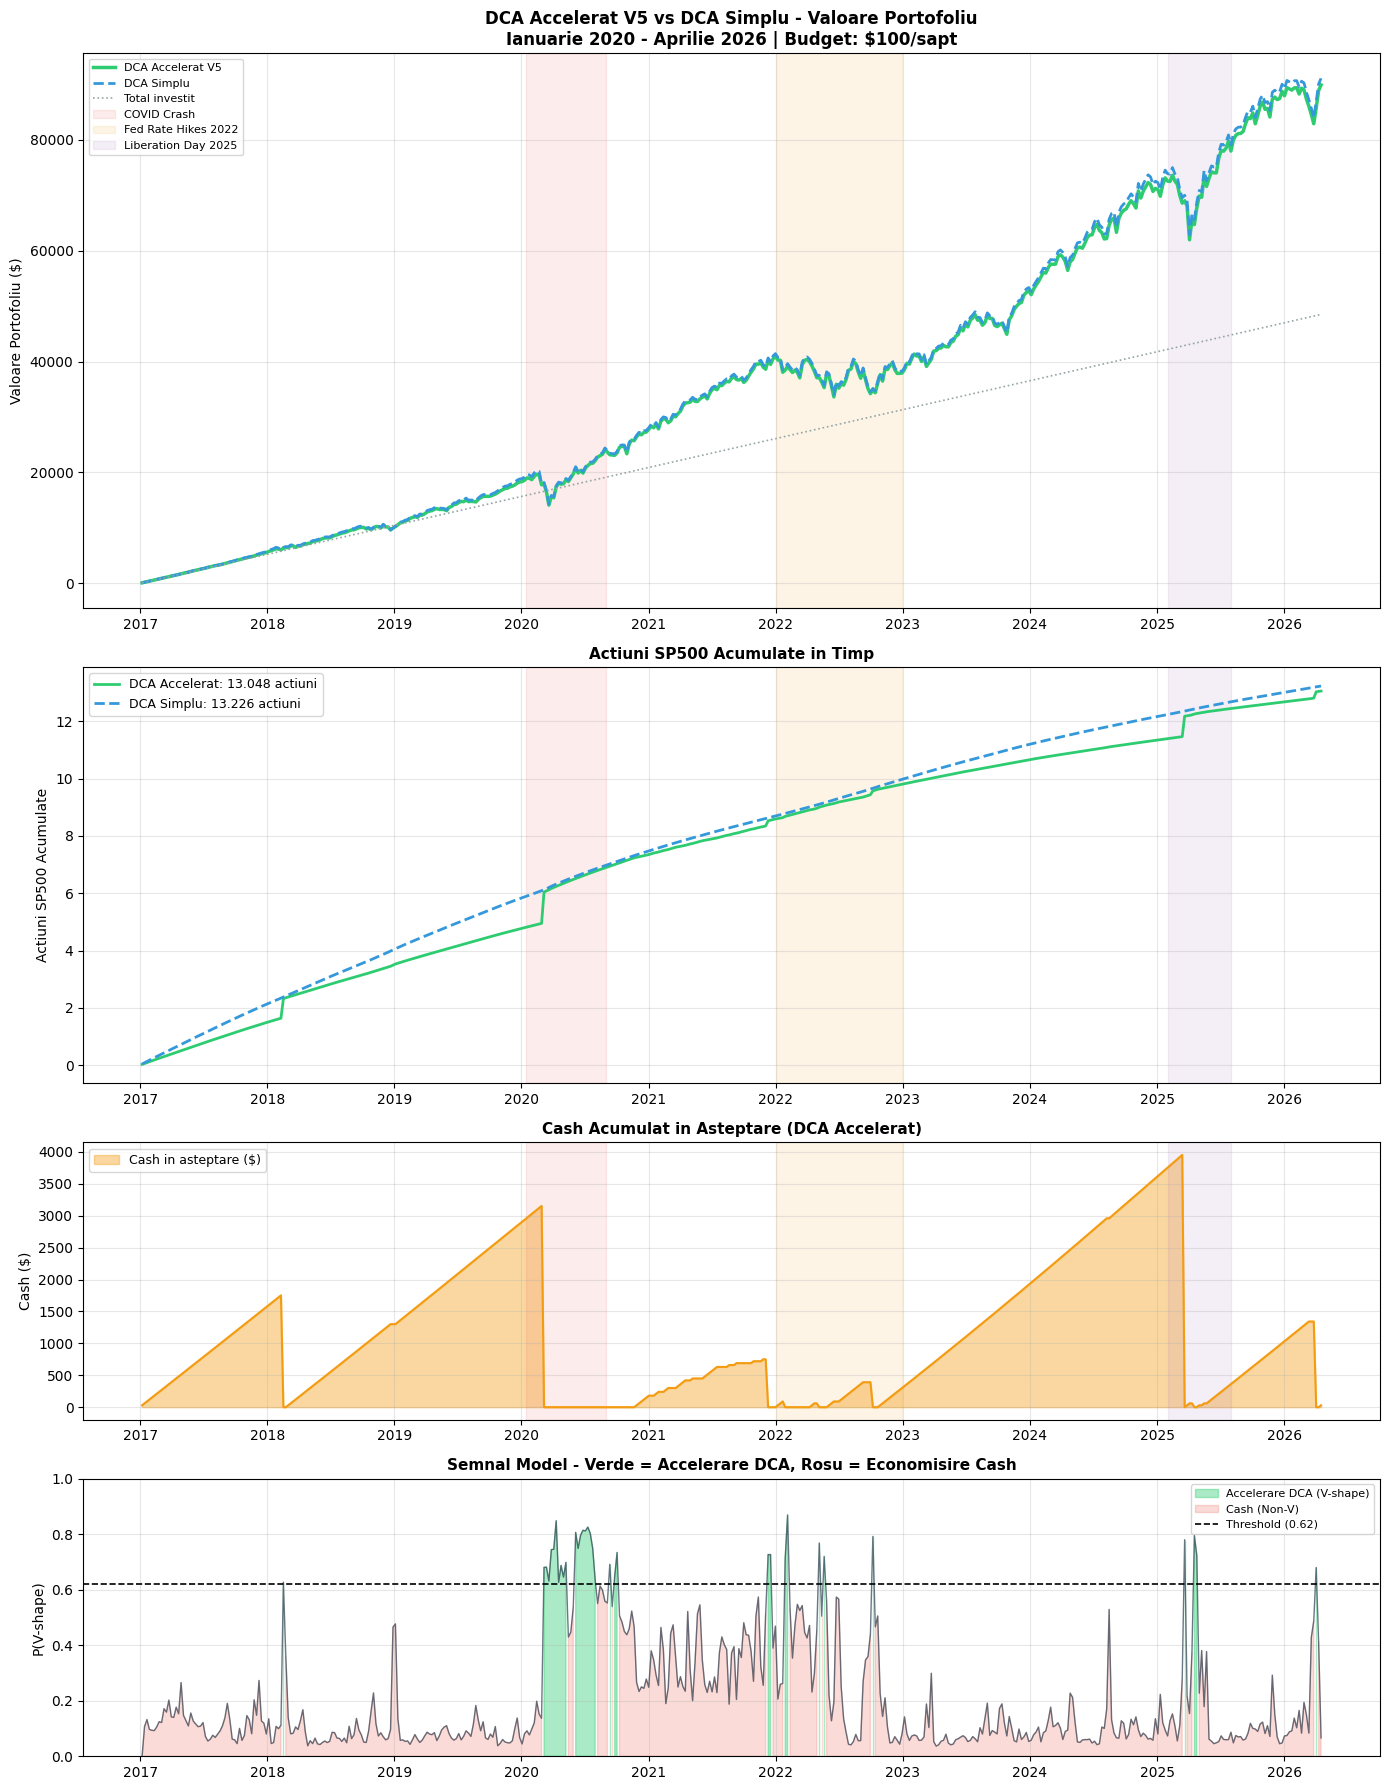

Salvat: plots/economic_significance_v3_dca.png


In [32]:
crises = [
    {'name': 'COVID Crash',         'start': '2020-01-15', 'end': '2020-08-31', 'color': '#e74c3c'},
    {'name': 'Fed Rate Hikes 2022', 'start': '2022-01-01', 'end': '2022-12-31', 'color': '#f39c12'},
    {'name': 'Liberation Day 2025', 'start': '2025-02-01', 'end': '2025-08-01', 'color': '#9b59b6'},
]

fig, axes = plt.subplots(4, 1, figsize=(14, 18),
                         gridspec_kw={'height_ratios': [2, 1.5, 1, 1]})

# --- Plot 1: Valore Portofoliu ---
ax1 = axes[0]
ax1.plot(acc_df.index, acc_df['Portfolio_Val'],
         color='#2ecc71', linewidth=2.5, label='DCA Accelerat V5')
ax1.plot(dca_df.index, dca_df['Portfolio_Val'],
         color='#3498db', linewidth=2, linestyle='--', label='DCA Simplu')
ax1.plot(dca_df.index, dca_df['Total_Invested'],
         color='#95a5a6', linewidth=1.2, linestyle=':', label='Total investit')

for c in crises:
    ax1.axvspan(pd.to_datetime(c['start']), pd.to_datetime(c['end']),
                alpha=0.10, color=c['color'], label=c['name'])

ax1.set_ylabel('Valoare Portofoliu ($)')
ax1.set_title('DCA Accelerat V5 vs DCA Simplu - Valoare Portofoliu\n' +
              'Ianuarie 2020 - Aprilie 2026 | Budget: $' + str(WEEKLY_BUDGET) + '/sapt',
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Actiuni Acumulate ---
ax2 = axes[1]
ax2.plot(acc_df.index, acc_df['Shares'],
         color='#2ecc71', linewidth=2, label='DCA Accelerat: ' + str(round(acc_shares_final, 3)) + ' actiuni')
ax2.plot(dca_df.index, dca_df['Shares'],
         color='#3498db', linewidth=2, linestyle='--',
         label='DCA Simplu: ' + str(round(dca_shares_final, 3)) + ' actiuni')

for c in crises:
    ax2.axvspan(pd.to_datetime(c['start']), pd.to_datetime(c['end']),
                alpha=0.10, color=c['color'])

ax2.set_ylabel('Actiuni SP500 Acumulate')
ax2.set_title('Actiuni SP500 Acumulate in Timp', fontsize=11, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Plot 3: Cash acumulat in DCA Accelerat ---
ax3 = axes[2]
ax3.fill_between(acc_df.index, acc_df['Cash'], 0,
                 alpha=0.4, color='#f39c12', label='Cash in asteptare ($)')
ax3.plot(acc_df.index, acc_df['Cash'], color='#f39c12', linewidth=1.5)

for c in crises:
    ax3.axvspan(pd.to_datetime(c['start']), pd.to_datetime(c['end']),
                alpha=0.10, color=c['color'])

ax3.set_ylabel('Cash ($)')
ax3.set_title('Cash Acumulat in Asteptare (DCA Accelerat)', fontsize=11, fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

# --- Plot 4: Semnal V5 ---
ax4 = axes[3]
ax4.fill_between(weekly_bt.index, proba_s, 0,
                 where=signal_s == 1, alpha=0.4, color='#2ecc71',
                 label='Accelerare DCA (V-shape)')
ax4.fill_between(weekly_bt.index, proba_s, 0,
                 where=signal_s == 0, alpha=0.2, color='#e74c3c',
                 label='Cash (Non-V)')
ax4.plot(weekly_bt.index, proba_s, color='#2c3e50', linewidth=1, alpha=0.7)
ax4.axhline(OPTIMAL_THRESHOLD, color='black', linestyle='--', linewidth=1.2,
            label='Threshold (' + str(OPTIMAL_THRESHOLD) + ')')
ax4.set_ylabel('P(V-shape)')
ax4.set_ylim(0, 1)
ax4.set_title('Semnal Model - Verde = Accelerare DCA, Rosu = Economisire Cash',
              fontsize=11, fontweight='bold')
ax4.legend(loc='upper right', fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/economic_significance_v3_dca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/economic_significance_v3_dca.png')

## 8. Analiza per An

In [33]:
# Reconstruim log-ul anual
dca_df['Year']    = dca_df.index.year
acc_df['Year']    = acc_df.index.year
sig_df            = pd.DataFrame({'Signal': signal_s, 'Year': weekly_bt.index.year})

yearly = []
for year in sorted(dca_df['Year'].unique()):
    dca_y   = dca_df[dca_df['Year'] == year]
    acc_y   = acc_df[acc_df['Year'] == year]
    sig_y   = sig_df[sig_df['Year'] == year]

    dca_start = dca_y['Portfolio_Val'].iloc[0]
    dca_end   = dca_y['Portfolio_Val'].iloc[-1]
    acc_start = acc_y['Portfolio_Val'].iloc[0]
    acc_end   = acc_y['Portfolio_Val'].iloc[-1]

    yearly.append({
        'Year'              : year,
        'DCA_Val_End'       : round(dca_end, 0),
        'ACC_Val_End'       : round(acc_end, 0),
        'DCA_Shares_End'    : round(dca_y['Shares'].iloc[-1], 4),
        'ACC_Shares_End'    : round(acc_y['Shares'].iloc[-1], 4),
        'Pct_VShape'        : round(sig_y['Signal'].mean() * 100, 1),
        'ACC_Cash_End'      : round(acc_y['Cash'].iloc[-1], 0)
    })

yearly_df = pd.DataFrame(yearly)
print('PERFORMANTA PER AN')
print('=' * 75)
print(yearly_df.to_string(index=False))
print()
print('Pct_VShape = % saptamani cu semnal V-shape in acel an')
print('ACC_Cash_End = cash ramas la sfarsitul anului in DCA Accelerat')

PERFORMANTA PER AN
 Year  DCA_Val_End  ACC_Val_End  DCA_Shares_End  ACC_Shares_End  Pct_VShape  ACC_Cash_End
 2017       5683.0       5547.0          2.1255          1.4878         0.0        1569.0
 2018      10001.0       9980.0          4.0235          3.4915         1.9        1301.0
 2019      18827.0      18279.0          5.8107          4.7544         0.0        2874.0
 2020      27578.0      27286.0          7.4472          7.3279        42.3         150.0
 2021      41434.0      40936.0          8.6934          8.5888         3.8           0.0
 2022      38283.0      37933.0          9.9707          9.8011         9.6         301.0
 2023      53355.0      52726.0         11.1859         10.6517         0.0        1919.0
 2024      72530.0      71237.0         12.1473         11.3301         0.0        3587.0
 2025      90022.0      88745.0         12.9903         12.6613         5.8        1003.0
 2026      91077.0      89885.0         13.2260         13.0485         6.2      

## 9. Fraze pentru Paper

In [34]:
shares_diff  = round(acc_shares_final - dca_shares_final, 4)
shares_pct   = round(shares_diff / dca_shares_final * 100, 2)
cost_diff    = round(dca_avg_cost - acc_avg_cost, 2)
cost_pct     = round(cost_diff / dca_avg_cost * 100, 2)
val_diff     = round(acc_final_val - dca_final_val, 2)

separator = '=' * 65
print('REZUMAT PENTRU PAPER')
print(separator)
print('Total investit (ambele):  $' + str(round(total_invested, 0)))
print('Actiuni DCA Simplu:       ' + str(round(dca_shares_final, 4)))
print('Actiuni DCA Accelerat:    ' + str(round(acc_shares_final, 4)),
      '(+' + str(shares_diff) + ', +' + str(shares_pct) + '%)')
print('Cost mediu DCA Simplu:   $' + str(round(dca_avg_cost, 2)))
print('Cost mediu DCA Accelerat:$' + str(round(acc_avg_cost, 2)),
      '(-$' + str(cost_diff) + ', -' + str(cost_pct) + '%)')
print('Valoare finala DCA:      $' + str(round(dca_final_val, 2)))
print('Valoare finala Accelerat:$' + str(round(acc_final_val, 2)),
      '(+$' + str(val_diff) + ')')
print()
print('FRAZA PENTRU PAPER:')
print(separator)
print('"We evaluate economic significance through a dollar-cost averaging')
print('strategy enhanced by the V5 Ensemble signal.')
print('An investor allocating $' + str(WEEKLY_BUDGET) + ' weekly accumulates cash')
print('during Non-V weeks (earning T-bill rate) and deploys the accumulated')
print('cash plus the weekly budget during V-shape weeks.')
print('Over the January 2020 - April 2026 out-of-sample period,')
print('both strategies deploy identical total capital of $' + str(round(total_invested, 0)) + '.')
print('The V5-enhanced DCA accumulates ' + str(round(acc_shares_final, 4)) + ' shares')
print('vs ' + str(round(dca_shares_final, 4)) + ' for naive DCA,')
print('a difference of +' + str(shares_pct) + '%, achieved through a lower average')
print('acquisition cost of $' + str(round(acc_avg_cost, 2)) + ' vs $' + str(round(dca_avg_cost, 2)) + ' (-' + str(cost_pct) + '%)."')

REZUMAT PENTRU PAPER
Total investit (ambele):  $48500.0
Actiuni DCA Simplu:       13.226
Actiuni DCA Accelerat:    13.0485 (+-0.1775, +-1.34%)
Cost mediu DCA Simplu:   $3667.03
Cost mediu DCA Accelerat:$3714.62 (-$-47.58, --1.3%)
Valoare finala DCA:      $91077.09
Valoare finala Accelerat:$89884.79 (+$-1192.31)

FRAZA PENTRU PAPER:
"We evaluate economic significance through a dollar-cost averaging
strategy enhanced by the V5 Ensemble signal.
An investor allocating $100 weekly accumulates cash
during Non-V weeks (earning T-bill rate) and deploys the accumulated
cash plus the weekly budget during V-shape weeks.
Over the January 2020 - April 2026 out-of-sample period,
both strategies deploy identical total capital of $48500.0.
The V5-enhanced DCA accumulates 13.0485 shares
vs 13.226 for naive DCA,
a difference of +-1.34%, achieved through a lower average
acquisition cost of $3714.62 vs $3667.03 (--1.3%)."
